# Graph link-prediction — `full_full` dataset (LORAX / Hladis M2OR)

> **Exploratory / rerun required.** Existing graph metrics use a provisional protocol (non-independent cold folds, train labels as MP edges, no validation-selected checkpoint) and are not final benchmark results. See `README.md`.

The most complete M2OR variant we have. Node features: **putative ESM-1b 650M mean** (proteins, distinct from curated/full ESM2; identity pending verification) + **ChemBERTa-77M** (molecules; the LORAX paper shows the molecule encoder is interchangeable, GIN covers only 64%). Reported head: unentangled **XGBoost** probe on `[raw ChemBERTa mol ‖ graph-enriched ESM prot]`.

**Two regimes** (rows of every plot):

- **transductive** — LORAX folds as-is: train/val = full noisy mix, test = EC50-only edges (~22% pos). All nodes known, edges held out (≈ stratified).
- **inductive_molecule** — cold start: whole molecules held out of the graph entirely, tested on their EC50 pairs (≈ group_molecule). Built in `orbind/lorax.py`; test stays EC50-only.

Grey bar = our plain `ESM‖ChemBERTa → XGBoost` baseline **on the same split, no graph** (`scripts/modeling/eval/eval_full_full_baseline.py`).

In [82]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve
from orbind.dataset import metrics

FOLD = 1   # which LORAX random fold to display (1..5)
# Clean stable-recipe grid ({gnn,gat} x {pos_only,all_edges,signed} x regimes),
# produced by scripts/modeling/train/run_graph_grid_v3.ps1 (same lr 1e-3 / grad-clip /
# ReduceLROnPlateau recipe as graph_rerun_v3; best_state restored before probe).
# The old provisional sweep (300ep, no best-val, default lr) is kept at
# results/graph/full_full/legacy/pre_v5/provisional_and_900_pilot/checkpoints — switch CKPT_DIR back to inspect it.
CKPT_DIR = ROOT / "results" / "graph" / "legacy" / "full_full" / "sweep_v3" / "full_full" / "checkpoints"
BASELINE_CSV = ROOT / "results" / "full_full" / "tables" / "baselines.csv"
REGIMES = ["transductive", "inductive_molecule"]
PLOT_METRICS = ["AUROC", "AUPRC", "MCC", "F1"]


def variant_of(ckpt):
    c = ckpt["config"]; v = c["mp_mode"]
    q = c.get("mol_quality_q", 0) or 0
    if q > 0: v += f"_q{int(q*100)}"
    if c.get("history", False):
        v += "_history" if c.get("history_depth", 2) >= 2 else "_hist1"
    if c.get("concat_raw_prot", False): v += "_rawp"
    if c.get("transductive_exp", False): v += "_transductive_exp"
    if c.get("disjoint_probe_train", False): v += "_disjoint"
    return v


print("ckpt_dir =", CKPT_DIR, "| fold =", FOLD)

ckpt_dir = <repo>\results\graph\legacy\full_full\sweep_v3\full_full\checkpoints | fold = 1


## v5 ? complete 900-epoch architecture screen

Primary protocol: **last checkpoint**, 900 epochs, no test evaluation during GNN training. Cache-miss reruns use lr=3e-3 and gradient clipping at 1.0; message passing uses the standard unfiltered graph, shared training data, and a raw-molecule XGBoost probe. Two encoder snapshots are retained: best validation AUPRC and last epoch; the primary probe uses the last snapshot.

Grid: `{GNN, GAT} ? {positive-only, all-edges, signed} ? {transductive, inductive molecule}`. Transductive evaluation uses three genuine LORAX folds; inductive evaluation uses three independent cold-molecule seeds. GNN and XGBoost receive distinct seeds, for **36 runs** total. Pre-v5 artifacts are isolated under `results/graph/full_full/legacy/`; this screen lives under `results/graph/full_full/v5/architecture_screen/`.


v5 completed: 36/36; collapse-masked: 0; last used: 36; best probes: 36/28


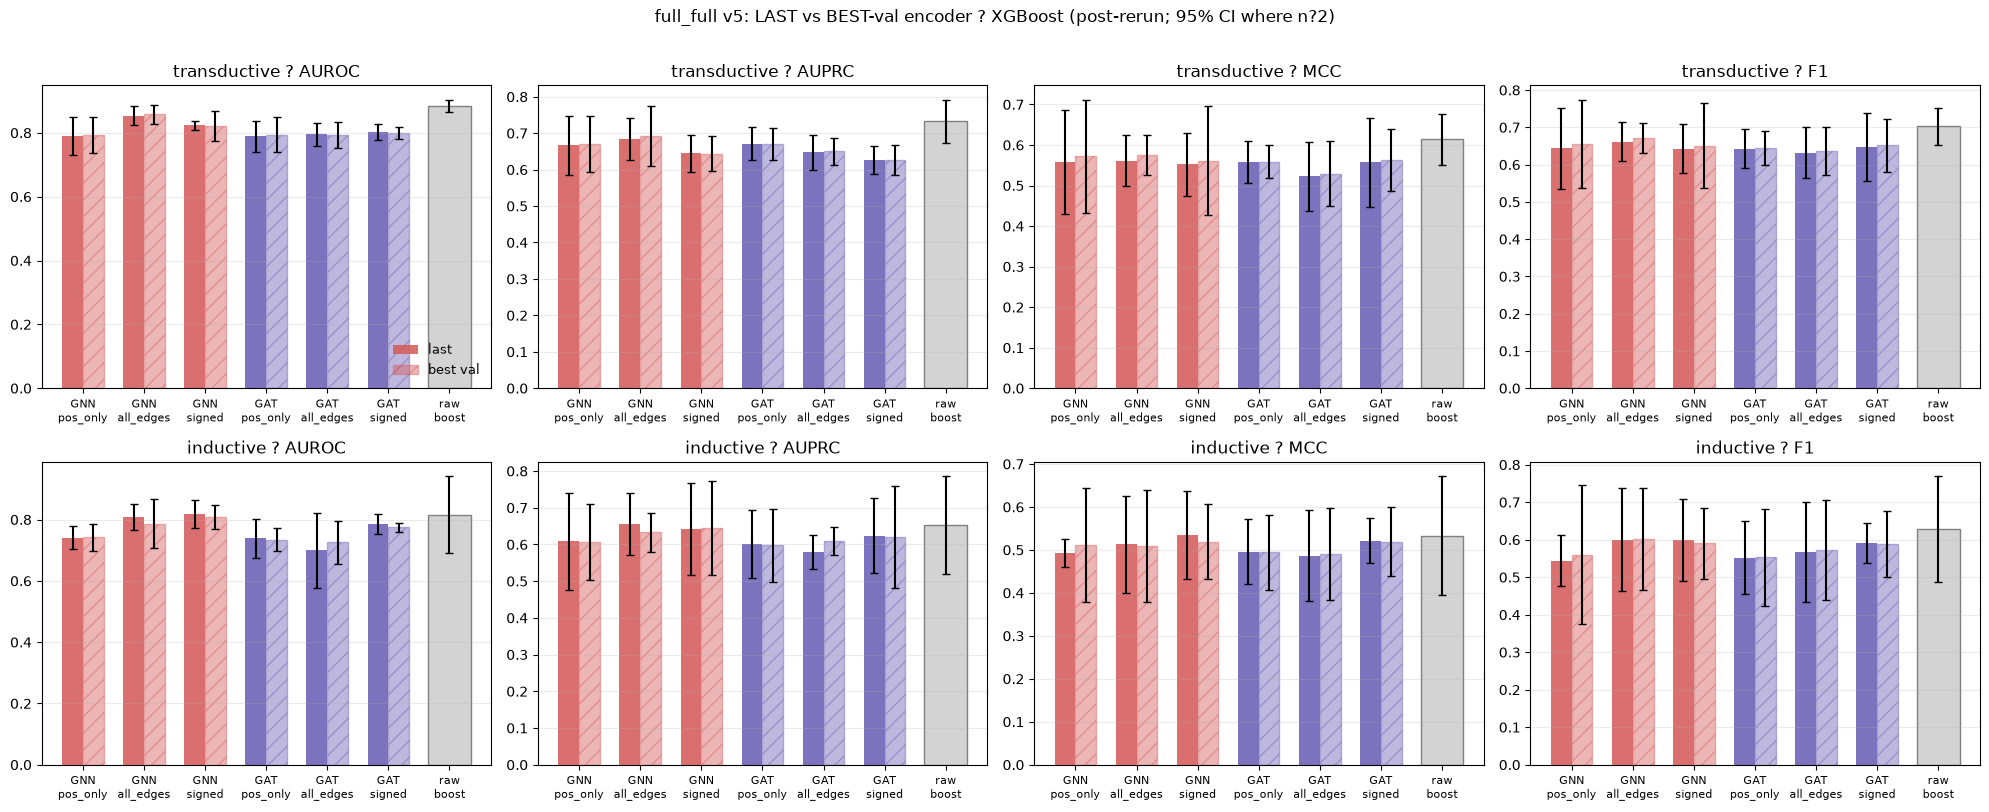

[Large run table omitted; rerun the cell to inspect the full table.]

In [85]:
# Load completed v5 runs and build the first architecture-comparison figure.
from scipy.stats import t as student_t

V5_ROOT = ROOT / "results/graph/full_full/v5/architecture_screen"
V5_CKPT = V5_ROOT / "training/checkpoints"
V5_BEST_PROBE = V5_ROOT / "probes/best_checkpoint"
V5_TABLES = V5_ROOT / "reports/tables"
V5_TABLES.mkdir(parents=True, exist_ok=True)

rows = []
if V5_CKPT.exists():
    for path in sorted(V5_CKPT.glob("*.pt")):
        ck = torch.load(path, map_location="cpu", weights_only=False)
        scores = ck.get("test_scores_final")
        if scores is None:
            continue
        y = ck["test_sup"][1].numpy()
        vals = metrics(y, np.asarray(scores))
        rows.append({
            "regime": ck["regime"], "arch": ck["arch"],
            "mp_mode": ck["config"]["mp_mode"], "fold": ck["fold"],
            "gnn_seed": ck.get("gnn_seed", ck.get("seed")),
            "boost_seed": ck.get("boost_seed"), "path": str(path), **vals,
        })

v5_runs_all = pd.DataFrame(rows)

# Runs excluded from aggregate statistics because their validation trajectory
# shows a persistent collapse, a terminal cliff, or strong collapse-like instability.
HISTORICAL_COLLAPSE_KEYS = {
    ("transductive", "gnn", "pos_only", 1, 42),
    ("transductive", "gnn", "signed", 1, 42),
    ("transductive", "gnn", "signed", 3, 44),
    ("transductive", "gnn", "all_edges", 2, 43),
    ("inductive_molecule", "gnn", "pos_only", 1, 43),
    ("inductive_molecule", "gnn", "pos_only", 1, 44),
    ("inductive_molecule", "gnn", "signed", 1, 42),
    ("inductive_molecule", "gnn", "signed", 1, 43),
}

# All eight targeted lr=3e-3 + clip=1.0 reruns passed the trajectory review.
COLLAPSE_MASK = set()

def collapse_key(row):
    return (row.regime, row.arch, row.mp_mode, int(row.fold), int(row.gnn_seed))

if len(v5_runs_all):
    suspect = v5_runs_all.apply(lambda row: collapse_key(row) in COLLAPSE_MASK, axis=1)
    excluded_runs = v5_runs_all[suspect].copy()
    v5_runs = v5_runs_all[~suspect].copy()
else:
    excluded_runs = v5_runs_all.copy()
    v5_runs = v5_runs_all.copy()

best_rows = []
if V5_BEST_PROBE.exists():
    for path in sorted(V5_BEST_PROBE.glob("*.pt")):
        rec = torch.load(path, map_location="cpu", weights_only=False)
        key = (rec["regime"], rec["arch"], rec["mp_mode"], int(rec["fold"]), int(rec["gnn_seed"]))
        if key in COLLAPSE_MASK:
            continue
        best_rows.append({
            "regime": rec["regime"], "arch": rec["arch"], "mp_mode": rec["mp_mode"],
            "fold": rec["fold"], "gnn_seed": rec["gnn_seed"],
            "boost_seed": rec["boost_seed"], "best_epoch": rec["best_epoch"],
            **{m: float(rec["test_metrics_best"][m]) for m in PLOT_METRICS},
        })
best_runs = pd.DataFrame(best_rows)

print(f"v5 completed: {len(v5_runs_all)}/36; collapse-masked: {len(excluded_runs)}; "
      f"last used: {len(v5_runs)}; best probes: {len(best_runs)}/28")
if len(v5_runs):
    summary = []
    for keys, group in v5_runs.groupby(["regime", "arch", "mp_mode"]):
        for metric in PLOT_METRICS:
            x = group[metric].astype(float)
            n = len(x); mean = x.mean(); sd = x.std(ddof=1) if n > 1 else np.nan
            half = (student_t.ppf(.975, n - 1) * sd / np.sqrt(n)) if n > 1 else np.nan
            summary.append(dict(zip(["regime", "arch", "mp_mode"], keys)) |
                           {"metric": metric, "mean": mean, "sd": sd, "n": n,
                            "ci_low": mean-half, "ci_high": mean+half})
    v5_summary = pd.DataFrame(summary)

    best_summary_rows = []
    if len(best_runs):
        for keys, group in best_runs.groupby(["regime", "arch", "mp_mode"]):
            for metric in PLOT_METRICS:
                x = group[metric].astype(float)
                n = len(x); mean = x.mean(); sd = x.std(ddof=1) if n > 1 else np.nan
                half = (student_t.ppf(.975, n - 1) * sd / np.sqrt(n)) if n > 1 else np.nan
                best_summary_rows.append(dict(zip(["regime", "arch", "mp_mode"], keys)) |
                                         {"metric": metric, "mean": mean, "sd": sd, "n": n,
                                          "ci_low": mean-half, "ci_high": mean+half})
    best_summary = pd.DataFrame(best_summary_rows)
    v5_runs.to_csv(V5_TABLES / "architecture_runs.csv", index=False)
    if len(best_runs):
        best_runs.to_csv(V5_TABLES / "architecture_best_checkpoint_runs.csv", index=False)
        best_summary.to_csv(V5_TABLES / "architecture_best_checkpoint_summary_ci95.csv", index=False)
    excluded_runs.to_csv(V5_TABLES / "excluded_collapse_runs.csv", index=False)
    v5_summary.to_csv(V5_TABLES / "architecture_summary_ci95.csv", index=False)

    # Matched raw-boost reference: exactly LORAX folds 1..3 for transductive
    # and exactly cold seeds 42..44 for inductive, matching the v5 repeats.
    baseline_runs = pd.read_csv(ROOT / "results/full_full/tables/baseline_runs.csv")
    matched = pd.concat([
        baseline_runs[(baseline_runs.regime == "transductive") &
                      (baseline_runs["repeat"].isin([1, 2, 3]))],
        baseline_runs[(baseline_runs.regime == "inductive_molecule") &
                      (baseline_runs["split_seed"].isin([42, 43, 44]))],
    ], ignore_index=True)
    baseline_rows = []
    for regime, group in matched.groupby("regime"):
        for metric in PLOT_METRICS:
            x = group[metric].astype(float); n = len(x); mean = x.mean(); sd = x.std(ddof=1)
            half = student_t.ppf(.975, n-1) * sd / np.sqrt(n)
            baseline_rows.append({"regime": regime, "metric": metric, "mean": mean,
                                  "ci_low": mean-half, "ci_high": mean+half, "n": n})
    baseline = pd.DataFrame(baseline_rows)
    labels = [("gnn", "pos_only"), ("gnn", "all_edges"), ("gnn", "signed"),
              ("gat", "pos_only"), ("gat", "all_edges"), ("gat", "signed")]
    colors = {"gnn": "#D65F5F", "gat": "#6F63B6"}
    width = .34
    fig, axes = plt.subplots(2, 4, figsize=(20, 8), sharey=False)
    for ri, regime in enumerate(REGIMES):
        for mi, metric in enumerate(PLOT_METRICS):
            ax = axes[ri, mi]
            sub_last = v5_summary[(v5_summary.regime == regime) & (v5_summary.metric == metric)]
            sub_best = (best_summary[(best_summary.regime == regime) & (best_summary.metric == metric)]
                        if len(best_summary) else best_summary)
            for xi, (arch, mp) in enumerate(labels):
                q = sub_last[(sub_last.arch == arch) & (sub_last.mp_mode == mp)]
                if len(q):
                    row = q.iloc[0]
                    err = None if row.n < 2 else [[row["mean"]-row.ci_low], [row.ci_high-row["mean"]]]
                    ax.bar(xi-width/2, row["mean"], width=width, color=colors[arch], alpha=.9,
                           yerr=err, capsize=3 if err is not None else 0,
                           label="last" if ri == 0 and mi == 0 and xi == 0 else None)
                q = sub_best[(sub_best.arch == arch) & (sub_best.mp_mode == mp)] if len(sub_best) else sub_best
                if len(q):
                    row = q.iloc[0]
                    err = None if row.n < 2 else [[row["mean"]-row.ci_low], [row.ci_high-row["mean"]]]
                    ax.bar(xi+width/2, row["mean"], width=width, color=colors[arch], alpha=.45,
                           hatch="//", edgecolor=colors[arch],
                           yerr=err, capsize=3 if err is not None else 0,
                           label="best val" if ri == 0 and mi == 0 and xi == 0 else None)
            b = baseline[(baseline.regime == regime) & (baseline.metric == metric)]
            if len(b):
                br = b.iloc[0]; xi = len(labels)
                ax.bar(xi, br["mean"], width=.7, color="lightgray", edgecolor="gray",
                       yerr=[[br["mean"]-br.ci_low], [br.ci_high-br["mean"]]], capsize=3)
            ax.set_xticks(range(len(labels)+1))
            ax.set_xticklabels([f"{a.upper()}\n{m}" for a,m in labels] + ["raw\nboost"],
                               rotation=0, fontsize=8)
            ax.set_title(f"{regime.replace('_molecule','')} ? {metric}")
            ax.grid(axis="y", alpha=.25)
    axes[0, 0].legend(frameon=False, fontsize=9)
    fig.suptitle("full_full v5: LAST vs BEST-val encoder ? XGBoost (post-rerun; 95% CI where n?2)", y=1.01)
    fig.tight_layout()
    plt.show()

    # Compact mean-results table after collapse masking (plus the matched raw baseline).
    graph_means = (v5_runs.groupby(["regime", "arch", "mp_mode"], as_index=False)
                   .agg(n=("AUPRC", "size"),
                        AUROC=("AUROC", "mean"), AUPRC=("AUPRC", "mean"),
                        MCC=("MCC", "mean"), F1=("F1", "mean")))
    graph_means["checkpoint"] = "last"
    if len(best_runs):
        best_means = (best_runs.groupby(["regime", "arch", "mp_mode"], as_index=False)
                      .agg(n=("AUPRC", "size"),
                           AUROC=("AUROC", "mean"), AUPRC=("AUPRC", "mean"),
                           MCC=("MCC", "mean"), F1=("F1", "mean")))
        best_means["checkpoint"] = "best_val"
        graph_means = pd.concat([graph_means, best_means], ignore_index=True)
    baseline_means = (matched.groupby("regime", as_index=False)
                      .agg(n=("AUPRC", "size"),
                           AUROC=("AUROC", "mean"), AUPRC=("AUPRC", "mean"),
                           MCC=("MCC", "mean"), F1=("F1", "mean")))
    baseline_means["arch"] = "baseline"
    baseline_means["mp_mode"] = "raw_boost"
    baseline_means["checkpoint"] = "raw"
    mean_results = (pd.concat([graph_means, baseline_means], ignore_index=True)
                    [["regime", "arch", "mp_mode", "checkpoint", "n", *PLOT_METRICS]]
                    .sort_values(["regime", "arch", "mp_mode", "checkpoint"]))
    mean_results.to_csv(V5_TABLES / "mean_results_collapse_masked.csv", index=False)
    display(mean_results.style.format({m: "{:.3f}" for m in PLOT_METRICS}).hide(axis="index"))
else:
    print("No v5 result bundles yet; run the launcher cell first.")


## v5 quantile screen - 5-repeat aggregation

Reads the server-side quantile sweep from `results/graph/full_full/v5/quantile_screen/training/checkpoints` and aggregates over five repeat points:

- transductive: LoRaX folds 1..5;
- inductive_molecule: cold-molecule seeds 42..46.

The table keeps both probe checkpoints (`best_val`, `last_epoch`); the plot uses `QUANTILE_PLOT_CHECKPOINT` below.


In [ ]:
# v5 quantile screen: bar-grid summary for GNN all_edges/signed over 5 repeat points.
# Reads completed checkpoints only; it does not launch training.

from scipy.stats import t as student_t

QS_ROOT = ROOT / "results/graph/full_full/v5/quantile_screen"
QS_TRAIN = QS_ROOT / "training"
QS_CKPT = QS_TRAIN / "checkpoints"
QS_TABLES = QS_ROOT / "reports/tables"
QS_FIGURES = QS_ROOT / "reports/figures"
QS_TABLES.mkdir(parents=True, exist_ok=True)
QS_FIGURES.mkdir(parents=True, exist_ok=True)

EXPECTED_REPEATS = {
    "transductive": {1, 2, 3, 4, 5},
    "inductive_molecule": {42, 43, 44, 45, 46},
}
EXPECTED_MP_MODES = ["all_edges", "signed"]
EXPECTED_QS = [0.0, 0.87, 0.95, 0.99]
CHECKPOINT_SCORE_KEYS = {
    "best_val": "test_scores",
    "last_epoch": "test_scores_final",
}
QUANTILE_PLOT_CHECKPOINT = "last_epoch"  # switch to "best_val" if needed


def _as_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def _q_clean(q):
    return round(float(q or 0.0), 2)


def _q_label(q):
    q = _q_clean(q)
    return "q0" if q == 0.0 else f"q{int(round(q * 100))}"


def _repeat_id(ck):
    # Transductive repeats are real LoRaX folds; inductive repeats are cold split seeds.
    if ck["regime"] == "transductive":
        return int(ck["fold"])
    return int(ck.get("gnn_seed", ck.get("seed")))


def _ci95_half(x):
    x = pd.Series(x).dropna().astype(float)
    if len(x) < 2:
        return np.nan
    return float(student_t.ppf(0.975, len(x) - 1) * x.std(ddof=1) / np.sqrt(len(x)))


quantile_rows = []
if QS_CKPT.exists():
    for path in sorted(QS_CKPT.glob("gnn_*_unentangled_boost_*.pt")):
        ck = torch.load(path, map_location="cpu", weights_only=False)
        cfg = ck.get("config", {})
        regime = ck.get("regime")
        mp_mode = cfg.get("mp_mode", ck.get("mp_mode"))
        q = _q_clean(cfg.get("mol_quality_q", 0.0))
        if ck.get("arch") != "gnn" or regime not in EXPECTED_REPEATS:
            continue
        if mp_mode not in EXPECTED_MP_MODES or q not in EXPECTED_QS:
            continue

        y = _as_numpy(ck["test_sup"][1])
        for checkpoint, score_key in CHECKPOINT_SCORE_KEYS.items():
            scores = ck.get(score_key)
            if scores is None:
                continue
            vals = metrics(y, _as_numpy(scores))
            quantile_rows.append({
                "regime": regime,
                "checkpoint": checkpoint,
                "arch": ck.get("arch"),
                "mp_mode": mp_mode,
                "mol_quality_q": q,
                "q_label": _q_label(q),
                "fold": int(ck["fold"]),
                "repeat_id": _repeat_id(ck),
                "gnn_seed": int(ck.get("gnn_seed", ck.get("seed"))),
                "boost_seed": int(ck.get("boost_seed", -1)),
                "path": str(path.relative_to(ROOT)),
                **vals,
            })

quantile_runs = pd.DataFrame(quantile_rows)
quantile_runs.to_csv(QS_TABLES / "quantile_runs_5repeat.csv", index=False)

if quantile_runs.empty:
    print(f"No completed quantile checkpoints found in {QS_CKPT}")
else:
    agg_spec = {}
    for m in PLOT_METRICS:
        agg_spec[f"{m}_mean"] = (m, "mean")
        agg_spec[f"{m}_std"] = (m, "std")
        agg_spec[f"{m}_ci95_half"] = (m, _ci95_half)

    quantile_summary = (
        quantile_runs
        .groupby(["regime", "checkpoint", "mp_mode", "mol_quality_q", "q_label"], as_index=False)
        .agg(n=("repeat_id", "nunique"), repeats=("repeat_id", lambda s: tuple(sorted(set(map(int, s))))), **agg_spec)
        .sort_values(["regime", "checkpoint", "mp_mode", "mol_quality_q"])
    )
    quantile_summary.to_csv(QS_TABLES / "quantile_summary_5repeat.csv", index=False)

    # Compact completeness check: no giant run tables in the notebook output.
    missing_lines = []
    for regime, expected in EXPECTED_REPEATS.items():
        for checkpoint in CHECKPOINT_SCORE_KEYS:
            for mp_mode in EXPECTED_MP_MODES:
                for q in EXPECTED_QS:
                    got = set(quantile_runs.loc[
                        (quantile_runs.regime == regime)
                        & (quantile_runs.checkpoint == checkpoint)
                        & (quantile_runs.mp_mode == mp_mode)
                        & (quantile_runs.mol_quality_q == q),
                        "repeat_id",
                    ].astype(int))
                    missing = sorted(expected - got)
                    if missing:
                        missing_lines.append(f"{regime} | {checkpoint} | {mp_mode} {_q_label(q)}: missing {missing}")
    print(f"quantile checkpoints: {quantile_runs['path'].nunique()} files; rows: {len(quantile_runs)}")
    if missing_lines:
        print("Incomplete groups:\n" + "\n".join(missing_lines))
    else:
        print("All quantile groups are complete: n=5 for best_val and last_epoch.")

    # Matched no-graph reference, averaged over the same 5-repeat protocol.
    baseline_mean = {r: {m: np.nan for m in PLOT_METRICS} for r in REGIMES}
    baseline_path = ROOT / "results/full_full/tables/baseline_runs.csv"
    if baseline_path.exists():
        baseline_runs = pd.read_csv(baseline_path)
        matched_baseline = baseline_runs[
            ((baseline_runs.regime == "transductive") & baseline_runs.repeat.astype(int).isin([1, 2, 3, 4, 5]))
            | ((baseline_runs.regime == "inductive_molecule") & baseline_runs.repeat.astype(int).isin([42, 43, 44, 45, 46]))
        ]
        for regime, group in matched_baseline.groupby("regime"):
            baseline_mean[regime] = {m: float(group[m].mean()) for m in PLOT_METRICS}
    else:
        print(f"No baseline file found: {baseline_path}")

    plot_df = quantile_summary[quantile_summary.checkpoint == QUANTILE_PLOT_CHECKPOINT].copy()
    method_specs = []
    for mp_mode, palette in [
        ("all_edges", ["#A8DDA8", "#78C679", "#41AB5D", "#238443"]),
        ("signed",    ["#FCBBA1", "#FC9272", "#FB6A4A", "#CB181D"]),
    ]:
        for q, color in zip(EXPECTED_QS, palette):
            method_specs.append((f"{mp_mode}\n{_q_label(q)}", color, mp_mode, q))
    names = [s[0] for s in method_specs] + ["XGBoost\n(no graph)"]
    colors = [s[1] for s in method_specs] + ["#A0A0A0"]

    fig, axes = plt.subplots(
        len(REGIMES), len(PLOT_METRICS),
        figsize=(1.2 * len(names) * len(PLOT_METRICS), 3.8 * len(REGIMES)),
    )
    axes = np.array(axes).reshape(len(REGIMES), len(PLOT_METRICS))

    for ri, regime in enumerate(REGIMES):
        for mi, metric in enumerate(PLOT_METRICS):
            ax = axes[ri, mi]
            vals, errs, ns = [], [], []
            for _, _, mp_mode, q in method_specs:
                row = plot_df[
                    (plot_df.regime == regime)
                    & (plot_df.mp_mode == mp_mode)
                    & (plot_df.mol_quality_q == q)
                ]
                vals.append(float(row[f"{metric}_mean"].iloc[0]) if len(row) else np.nan)
                errs.append(float(row[f"{metric}_ci95_half"].iloc[0]) if len(row) else np.nan)
                ns.append(int(row["n"].iloc[0]) if len(row) else 0)
            base = baseline_mean[regime][metric]
            vals = vals + [base]
            errs = errs + [np.nan]
            ns = ns + [5 if np.isfinite(base) else 0]

            x = np.arange(len(names))
            bars = ax.bar(x, vals, yerr=errs, capsize=2.5, color=colors)
            if np.isfinite(base):
                ax.axhline(base, color="#A0A0A0", ls="--", lw=1)
            ax.set_title(f"{regime} ? {metric}", fontsize=9)
            ax.set_ylim(0, 1)
            ax.set_xticks(x)
            ax.set_xticklabels(names, rotation=45, ha="right", fontsize=6.5)
            ax.grid(alpha=.15, axis="y")
            for b, v, n in zip(bars, vals, ns):
                if np.isfinite(v):
                    label = f"{v:.3f}" if n == 5 else f"{v:.3f}\nn={n}"
                    ax.text(b.get_x() + b.get_width()/2, v + 0.02, label,
                            ha="center", va="bottom", fontsize=6.5)

    fig.suptitle(
        f"v5 quantile screen ? GNN unentangled XGBoost probe, {QUANTILE_PLOT_CHECKPOINT}, 5 repeats",
        fontsize=12, y=1.01,
    )
    plt.tight_layout()
    fig.savefig(QS_FIGURES / f"quantile_screen_{QUANTILE_PLOT_CHECKPOINT}_bar_grid_5repeat.png",
                dpi=150, bbox_inches="tight")
    plt.show()


### signed q99 feature-probe ablation

Downstream XGBoost probes over the already trained `gnn signed q99` encoder. Bars compare raw no-graph boosting, the standard signed-q99 graph probe, and protein-feature variants that add raw/pre-MP/intermediate protein representations.


In [ ]:
# signed q99 feature-probe ablation: same bar-grid style as the main graph figures.
FEATURE_PROBE_ROOT = ROOT / "results/graph/full_full/v5/signed_q99_feature_probes"
FEATURE_PROBE_FIGURES = FEATURE_PROBE_ROOT / "figures"
FEATURE_PROBE_FIGURES.mkdir(parents=True, exist_ok=True)
FEATURE_PROBE_CHECKPOINT = "last_epoch"  # switch to "best_val" after running that probe set
FEATURE_PROBE_RUNS = FEATURE_PROBE_ROOT / f"signed_q99_{FEATURE_PROBE_CHECKPOINT}_feature_probe_runs.csv"

FEATURE_VARIANT_LABELS = {
    "z2_rawmol": "GNN z2\n+ mol",
    "z2_rawprot_rawmol": "GNN z2\n+ raw prot",
    "z2_x0_rawmol": "GNN z2\n+ x0",
    "z2_rawprot_x0_x1_rawmol": "GNN z2\n+ raw+x0+x1",
}
FEATURE_VARIANT_COLORS = {
    "raw_boost": "#A0A0A0",
    "signed_q99_default": "#CB181D",
    "z2_rawmol": "#FCAE91",
    "z2_rawprot_rawmol": "#FB6A4A",
    "z2_x0_rawmol": "#9ECAE1",
    "z2_rawprot_x0_x1_rawmol": "#3182BD",
}

if not FEATURE_PROBE_RUNS.exists():
    print(f"No feature-probe CSV yet: {FEATURE_PROBE_RUNS}")
    print("Run: bash scripts/modeling/eval/run_graph_full_full_signed_q99_feature_probes.sh")
else:
    feature_runs = pd.read_csv(FEATURE_PROBE_RUNS)
    feature_runs.to_csv(FEATURE_PROBE_ROOT / f"signed_q99_{FEATURE_PROBE_CHECKPOINT}_feature_probe_runs.copy.csv", index=False)

    # Standard signed q99 graph probe from the quantile checkpoints, for a direct reference column.
    if "quantile_runs" not in globals() or quantile_runs.empty:
        print("Run the quantile-screen cell first; it defines quantile_runs used for the signed-q99 reference.")
    else:
        signed_ref = quantile_runs[
            (quantile_runs.checkpoint == FEATURE_PROBE_CHECKPOINT)
            & (quantile_runs.mp_mode == "signed")
            & (quantile_runs.mol_quality_q == 0.99)
        ].copy()

        baseline_path = ROOT / "results/full_full/tables/baseline_runs.csv"
        baseline_runs = pd.read_csv(baseline_path) if baseline_path.exists() else pd.DataFrame()
        if len(baseline_runs):
            baseline_runs = baseline_runs[
                ((baseline_runs.regime == "transductive") & baseline_runs.repeat.astype(int).isin([1, 2, 3, 4, 5]))
                | ((baseline_runs.regime == "inductive_molecule") & baseline_runs.repeat.astype(int).isin([42, 43, 44, 45, 46]))
            ].copy()

        plot_specs = [
            ("XGBoost\n(no graph)", "raw_boost"),
            ("signed q99\ndefault", "signed_q99_default"),
            (FEATURE_VARIANT_LABELS["z2_rawmol"], "z2_rawmol"),
            (FEATURE_VARIANT_LABELS["z2_rawprot_rawmol"], "z2_rawprot_rawmol"),
            (FEATURE_VARIANT_LABELS["z2_x0_rawmol"], "z2_x0_rawmol"),
            (FEATURE_VARIANT_LABELS["z2_rawprot_x0_x1_rawmol"], "z2_rawprot_x0_x1_rawmol"),
        ]
        names = [s[0] for s in plot_specs]
        colors = [FEATURE_VARIANT_COLORS[s[1]] for s in plot_specs]

        def _mean_metric(source, regime, metric):
            if source == "raw_boost":
                g = baseline_runs[baseline_runs.regime == regime] if len(baseline_runs) else pd.DataFrame()
                repeat_col = "repeat"
            elif source == "signed_q99_default":
                g = signed_ref[signed_ref.regime == regime]
                repeat_col = "repeat_id"
            else:
                g = feature_runs[(feature_runs.regime == regime) & (feature_runs.variant == source)]
                repeat_col = "repeat_id"
            if len(g) == 0:
                return np.nan, 0
            n = int(g[repeat_col].nunique()) if repeat_col in g.columns else len(g)
            return float(g[metric].mean()), n

        fig, axes = plt.subplots(
            len(REGIMES), len(PLOT_METRICS),
            figsize=(1.2 * len(names) * len(PLOT_METRICS), 3.8 * len(REGIMES)),
        )
        axes = np.array(axes).reshape(len(REGIMES), len(PLOT_METRICS))

        missing_lines = []
        for ri, regime in enumerate(REGIMES):
            for mi, metric in enumerate(PLOT_METRICS):
                ax = axes[ri, mi]
                vals, ns = [], []
                for _, source in plot_specs:
                    v, n = _mean_metric(source, regime, metric)
                    vals.append(v)
                    ns.append(n)
                    if n not in (0, 5):
                        missing_lines.append(f"{regime} | {source}: n={n}")
                x = np.arange(len(names))
                bars = ax.bar(x, vals, color=colors)
                base = vals[0]
                if np.isfinite(base):
                    ax.axhline(base, color="#A0A0A0", ls="--", lw=1)
                ax.set_title(f"{regime} ? {metric}", fontsize=9)
                ax.set_ylim(0, 1)
                ax.set_xticks(x)
                ax.set_xticklabels(names, rotation=45, ha="right", fontsize=6.5)
                ax.grid(alpha=.15, axis="y")
                for b, v, n in zip(bars, vals, ns):
                    if np.isfinite(v):
                        label = f"{v:.3f}" if n == 5 else f"{v:.3f}\nn={n}"
                        ax.text(b.get_x() + b.get_width()/2, v + 0.02, label,
                                ha="center", va="bottom", fontsize=6.5)

        if missing_lines:
            print("Incomplete feature-probe groups:\n" + "\n".join(sorted(set(missing_lines))))
        else:
            print("All feature-probe groups shown with n=5.")
        fig.suptitle(
            f"signed q99 feature-probe ablation ? {FEATURE_PROBE_CHECKPOINT}, 5 repeats",
            fontsize=12, y=1.01,
        )
        plt.tight_layout()
        fig.savefig(FEATURE_PROBE_FIGURES / f"signed_q99_feature_probe_ablation_{FEATURE_PROBE_CHECKPOINT}.png",
                    dpi=150, bbox_inches="tight")
        plt.show()


### ROC: inductive GNN all-edges, last/best versus raw boosting

Only the `inductive_molecule` regime is shown, using cold-split seeds 42..46. Curves are interpolated onto a common FPR grid; the solid line is the mean and the band is the 95% t-confidence interval. The raw baseline is refitted separately for each cold split.


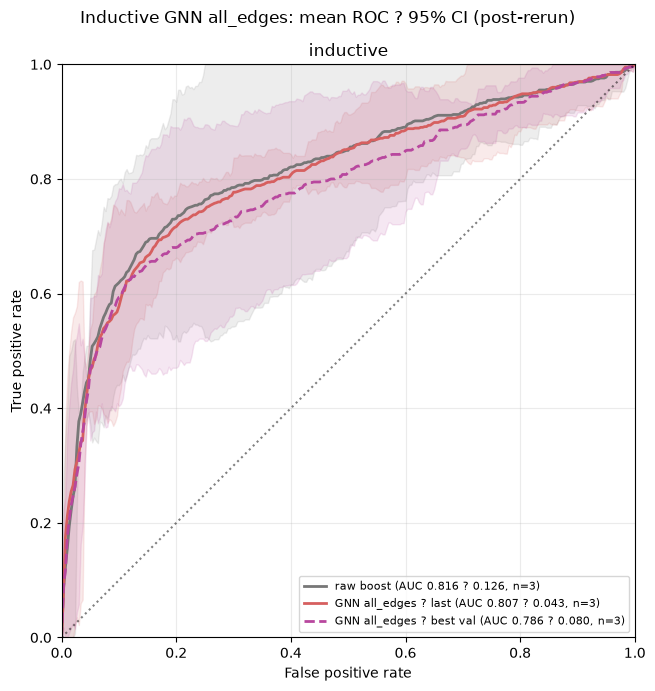

regime,model,n,AUROC_mean,AUROC_ci95_half
inductive_molecule,raw boost,3,0.816,0.126
inductive_molecule,GNN all_edges ? last,3,0.807,0.043
inductive_molecule,GNN all_edges ? best val,3,0.786,0.080


In [86]:
# Mean ROC curves with 95% t-CI: GNN all_edges (last / best-val) vs raw boost.
from scipy.stats import t as student_t
from sklearn.metrics import roc_auc_score
from orbind import lorax as L
from orbind.baselines import train_boost

ROC_CACHE = V5_ROOT / "probes/raw_baseline_roc"
ROC_CACHE.mkdir(parents=True, exist_ok=True)
ROC_PLOTS = V5_ROOT / "reports/figures"
ROC_PLOTS.mkdir(parents=True, exist_ok=True)


def raw_xy(split, Xm, Xp):
    pairs = np.concatenate([split["pos"], split["neg"]], axis=0)
    y = np.concatenate([np.ones(len(split["pos"])), np.zeros(len(split["neg"]))])
    X = np.concatenate([Xm[pairs[:, 0]], Xp[pairs[:, 1]]], axis=1)
    return X, y


# Reproduce the matched raw baseline and cache pair-level probabilities.
baseline_specs = [
    ("inductive_molecule", 1, seed)
    for seed in [42, 43, 44, 45, 46]
]
esm, chem = None, None
for regime, fold, split_seed in baseline_specs:
    repeat = f"fold{fold}" if regime == "transductive" else f"cold{split_seed}"
    out = ROC_CACHE / f"raw_boost_{regime}_{repeat}.pt"
    if out.exists():
        continue
    if esm is None:
        esm, chem = L.load_embeddings()
    Xm, Xp, splits = L.build(regime, fold, esm, chem, seed=split_seed)
    Xtr, ytr = raw_xy(splits["train"], Xm.numpy(), Xp.numpy())
    Xte, yte = raw_xy(splits["test"], Xm.numpy(), Xp.numpy())
    # Match eval_full_full_baseline.py: split varies, XGBoost seed stays fixed at 42.
    scores = train_boost(Xtr, ytr, Xte, seed=42)
    torch.save({"regime": regime, "fold": fold, "split_seed": split_seed,
                "y": yte, "scores": scores}, out)
    print("cached", out.name)


def key_of(rec):
    return (rec["regime"], rec["arch"], rec["config"]["mp_mode"],
            int(rec["fold"]), int(rec.get("gnn_seed", rec["seed"])))


ROC_REGIMES = ["inductive_molecule"]
roc_sets = {r: {"raw boost": [], "GNN all_edges ? last": [],
                "GNN all_edges ? best val": []} for r in ROC_REGIMES}

for path in sorted(V5_CKPT.glob("gnn_all_edges_*.pt")):
    ck = torch.load(path, map_location="cpu", weights_only=False)
    if ck["regime"] not in ROC_REGIMES or key_of(ck) in COLLAPSE_MASK:
        continue
    roc_sets[ck["regime"]]["GNN all_edges ? last"].append(
        (ck["test_sup"][1].numpy(), np.asarray(ck["test_scores_final"])))

if V5_BEST_PROBE.exists():
    for path in sorted(V5_BEST_PROBE.glob("gnn_all_edges_*.pt")):
        rec = torch.load(path, map_location="cpu", weights_only=False)
        key = (rec["regime"], rec["arch"], rec["mp_mode"],
               int(rec["fold"]), int(rec["gnn_seed"]))
        if rec["regime"] not in ROC_REGIMES or key in COLLAPSE_MASK:
            continue
        source = V5_CKPT / path.name
        ck = torch.load(source, map_location="cpu", weights_only=False)
        roc_sets[rec["regime"]]["GNN all_edges ? best val"].append(
            (ck["test_sup"][1].numpy(), np.asarray(rec["test_scores_best"])))

for path in sorted(ROC_CACHE.glob("raw_boost_inductive_molecule_*.pt")):
    rec = torch.load(path, map_location="cpu", weights_only=False)
    roc_sets[rec["regime"]]["raw boost"].append((np.asarray(rec["y"]), np.asarray(rec["scores"])))


def mean_roc(samples, grid):
    curves, aucs = [], []
    for y, score in samples:
        fpr, tpr, _ = roc_curve(y, score)
        curve = np.interp(grid, fpr, tpr)
        curve[0] = 0.0; curve[-1] = 1.0
        curves.append(curve); aucs.append(roc_auc_score(y, score))
    curves = np.asarray(curves); aucs = np.asarray(aucs)
    n = len(curves); mean = curves.mean(axis=0)
    if n >= 2:
        half = student_t.ppf(.975, n-1) * curves.std(axis=0, ddof=1) / np.sqrt(n)
        auc_half = student_t.ppf(.975, n-1) * aucs.std(ddof=1) / np.sqrt(n)
    else:
        half = np.zeros_like(mean); auc_half = np.nan
    return mean, np.clip(mean-half, 0, 1), np.clip(mean+half, 0, 1), aucs.mean(), auc_half, n


styles = {
    "raw boost": ("#777777", "-"),
    "GNN all_edges ? last": ("#D65F5F", "-"),
    "GNN all_edges ? best val": ("#B8479E", "--"),
}
grid = np.linspace(0, 1, 301)
fig, ax = plt.subplots(1, 1, figsize=(7, 7))
roc_summary_rows = []
for regime in ROC_REGIMES:
    for label, samples in roc_sets[regime].items():
        if not samples:
            continue
        mean, low, high, auc, auc_half, n = mean_roc(samples, grid)
        color, ls = styles[label]
        ci_text = f" ? {auc_half:.3f}" if np.isfinite(auc_half) else ""
        ax.plot(grid, mean, color=color, ls=ls, lw=2,
                label=f"{label} (AUC {auc:.3f}{ci_text}, n={n})")
        if n >= 2:
            ax.fill_between(grid, low, high, color=color, alpha=.13)
        roc_summary_rows.append({"regime": regime, "model": label, "n": n,
                                 "AUROC_mean": auc, "AUROC_ci95_half": auc_half})
    ax.plot([0, 1], [0, 1], ":", color="black", alpha=.5)
    ax.set_title(regime.replace("_molecule", ""))
    ax.set_xlabel("False positive rate")
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=.25)
    ax.legend(fontsize=8, loc="lower right")
ax.set_ylabel("True positive rate")
fig.suptitle("Inductive GNN all_edges: mean ROC ? 95% CI (post-rerun)")
fig.tight_layout()
fig.savefig(ROC_PLOTS / "roc_inductive_gnn_all_edges_last_best_vs_raw_boost.png", dpi=180, bbox_inches="tight")
plt.show()

roc_summary = pd.DataFrame(roc_summary_rows)
roc_summary.to_csv(V5_TABLES / "roc_inductive_gnn_all_edges_last_best_vs_raw_boost.csv", index=False)
display(roc_summary.style.format({"AUROC_mean": "{:.3f}", "AUROC_ci95_half": "{:.3f}"}).hide(axis="index"))


## Clean rerun: protocol comparison (1500 epochs, best-val checkpoint)

Isolated run from `results/graph/full_full/legacy/pre_v5/rerun_v3/full_full/` — never mix with the old sweep in `results/full_full/`.  
Five protocols crossing **supervision strategy** (shared / disjoint probe train) and **molecule input** (raw / graph-enriched) for `signed` GNN, produced from **4 training runs** — each transductive run yields both the raw-ChemBERTa and graph-enriched probe from a single GNN training (`test_scores_raw` / `test_scores_enriched`).  
Stable recipe: `--lr 1e-3 --grad-clip 1.0 --lr-scheduler` (ReduceLROnPlateau, patience 100). The v2 runs collapsed after their best epoch (logit explosion → AUROC 0.5); v3 stays stable to 1500 epochs. `best_state` (best-val encoder) is restored before every probe.  
Missing bars = that command hasn't run yet; the inductive regime has no enriched-molecule row by design.

In [87]:
RERUN_CKPT_DIR = ROOT / "results" / "graph_rerun_v3" / "full_full" / "checkpoints"

rerun_records, rerun_preds = [], {}

def _add_entry(ckpt, y, scores, var_override=None):
    regime, arch = ckpt["regime"], ckpt["arch"]
    var = var_override if var_override is not None else variant_of(ckpt)
    history = pd.DataFrame(ckpt.get("decoder_history", []))
    best_ep = (int(history.loc[history["val_AUPRC"].idxmax(), "epoch"])
               if not history.empty and "val_AUPRC" in history.columns else float("nan"))
    rerun_records.append({"regime": regime, "arch": arch, "variant": var,
                          "best_epoch": best_ep, **metrics(y, scores)})
    rerun_preds[(regime, arch, var)] = (y, scores)

for path in sorted(RERUN_CKPT_DIR.glob(f"*_fold{FOLD}.pt")):
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    _, test_y = ckpt["test_sup"]
    y = test_y.numpy()

    # Primary variant (test_scores is always the run's main probe)
    _add_entry(ckpt, y, np.asarray(ckpt["test_scores"]))

    # Bonus: if this checkpoint also stored the complementary transductive probe,
    # synthesize a second entry so we don't need a separate training run.
    cfg = ckpt["config"]
    if ckpt["regime"] == "transductive":
        if not cfg.get("transductive_exp", False) and ckpt.get("test_scores_enriched") is not None:
            base_var = variant_of(ckpt)
            enr_var = base_var + "_transductive_exp"
            _add_entry(ckpt, y, np.asarray(ckpt["test_scores_enriched"]), var_override=enr_var)
        elif cfg.get("transductive_exp", False) and ckpt.get("test_scores_raw") is not None:
            base_var = variant_of(ckpt).replace("_transductive_exp", "")
            _add_entry(ckpt, y, np.asarray(ckpt["test_scores_raw"]), var_override=base_var)

rerun_df = (pd.DataFrame(rerun_records)
            .set_index(["regime", "arch", "variant"]).sort_index().round(3)
            if rerun_records else pd.DataFrame())
print(f"{len(rerun_preds)} clean-rerun entries loaded  |  rerun_dir = {RERUN_CKPT_DIR}")
display(rerun_df)

0 clean-rerun entries loaded  |  rerun_dir = <repo>\results\graph_rerun_v3\full_full\checkpoints


""


In [88]:
# Load every full_full checkpoint for FOLD, keyed by (regime, arch, variant).
# variant = mp_mode [+ _q##] [+ _history]  — fully identifies a run.
records, preds = [], {}
for path in sorted(CKPT_DIR.glob(f"*_fold{FOLD}.pt")):
    ckpt = torch.load(path, map_location="cpu", weights_only=False)
    regime, arch, var = ckpt["regime"], ckpt["arch"], variant_of(ckpt)
    _, test_y = ckpt["test_sup"]
    y, scores = test_y.numpy(), ckpt["test_scores"]
    records.append({"regime": regime, "arch": arch, "variant": var, **metrics(y, scores)})
    preds[(regime, arch, var)] = (y, scores)

df = (pd.DataFrame(records).set_index(["regime", "arch", "variant"]).sort_index().round(3)
      if records else pd.DataFrame())
print(f"{len(preds)} checkpoints loaded")
display(df)

24 checkpoints loaded


[Large run table omitted; rerun the cell to inspect the full table.]

In [89]:
# No-graph XGBoost baseline on the SAME splits (both regimes) — the bar to beat
bl = pd.read_csv(BASELINE_CSV).set_index("regime")
BASE = {r: {m: float(bl.loc[r, m]) for m in PLOT_METRICS} for r in REGIMES}
for r in REGIMES:
    print(f"{r:20s} no-graph boost:", {k: round(v, 3) for k, v in BASE[r].items()})

transductive         no-graph boost: {'AUROC': 0.892, 'AUPRC': 0.757, 'MCC': 0.63, 'F1': 0.715}
inductive_molecule   no-graph boost: {'AUROC': 0.812, 'AUPRC': 0.653, 'MCC': 0.523, 'F1': 0.625}


In [90]:
# Reusable: rows = regimes, cols = metrics; bars = listed (arch, variant) + baseline
def _wrap(name):
    """Break long bar labels into two lines for readability."""
    if "\n" in name:
        return name
    if " · " in name:
        return name.replace(" · ", "\n", 1)
    parts = name.split(" ", 1)
    return "\n".join(parts) if len(name) > 8 and len(parts) > 1 else name

def plot_grid(specs, suptitle, savename, rot=0, fs=7, src_df=None, src_preds=None):
    """specs: list of (display_name, color, arch, variant).
    src_df / src_preds: override the global df/preds (e.g. for rerun checkpoints).
    """
    _df    = src_df    if src_df    is not None else df
    _preds = src_preds if src_preds is not None else preds
    names  = [_wrap(s[0]) for s in specs] + ["XGBoost\n(no graph)"]
    colors = [s[1] for s in specs] + ["#A0A0A0"]
    fig, axes = plt.subplots(len(REGIMES), len(PLOT_METRICS),
                              figsize=(1.2*len(names)*len(PLOT_METRICS), 3.8*len(REGIMES)))
    axes = np.array(axes).reshape(len(REGIMES), len(PLOT_METRICS))
    for ri, regime in enumerate(REGIMES):
        for mi, metric in enumerate(PLOT_METRICS):
            ax = axes[ri, mi]; base = BASE[regime][metric]
            vals = [_df.loc[(regime, a, v), metric] if (regime, a, v) in _df.index else float("nan")
                    for _, _, a, v in specs] + [base]
            bars = ax.bar(names, vals, color=colors)
            ax.axhline(base, color="#A0A0A0", ls="--", lw=1)
            ax.set_title(f"{regime} — {metric}", fontsize=9)
            ax.set_ylim(0, 1); ax.tick_params(axis="x", labelsize=fs, rotation=rot)
            for b, v in zip(bars, vals):
                if not np.isnan(v):
                    ax.text(b.get_x()+b.get_width()/2, v+0.02, f"{v:.3f}",
                            ha="center", va="bottom", fontsize=fs)
    fig.suptitle(suptitle, fontsize=12, y=1.01); plt.tight_layout()
    (ROOT/"notebooks/figures").mkdir(parents=True, exist_ok=True)
    plt.savefig(ROOT/f"notebooks/figures/{savename}.png", dpi=150, bbox_inches="tight")
    plt.show()

GNN_C = {"pos_only":"#4878CF","all_edges":"#6ACC65","signed":"#D65F5F"}
GAT_C = {"pos_only":"#3A5FA0","all_edges":"#4E9E4E","signed":"#9467BD"}

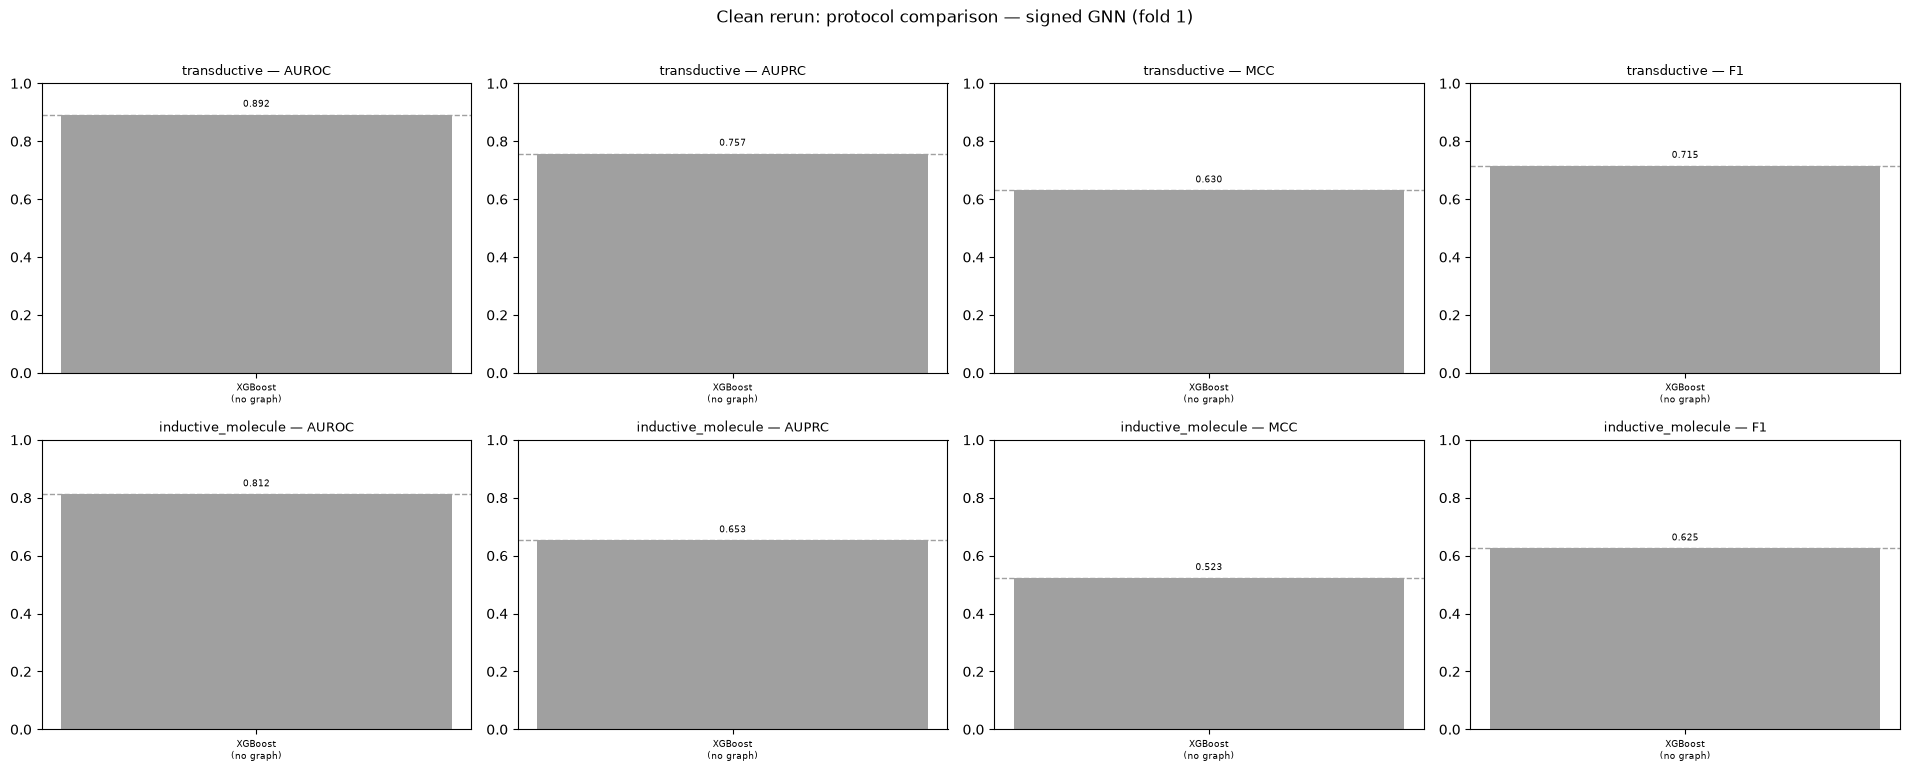

In [91]:
# Clean rerun: shared vs disjoint supervision, raw vs enriched molecule input
RERUN_C = {
    "shared_raw":      "#D65F5F",
    "shared_enriched": "#FF9F7F",
    "disjoint_raw":    "#7B3F9E",
}
specs_rerun = [
    ("shared · raw mol",      RERUN_C["shared_raw"],      "gnn", "signed"),
    ("shared · enriched mol", RERUN_C["shared_enriched"], "gnn", "signed_transductive_exp"),
    ("disjoint · raw mol",    RERUN_C["disjoint_raw"],    "gnn", "signed_disjoint"),
]
plot_grid(specs_rerun, f"Clean rerun: protocol comparison — signed GNN (fold {FOLD})",
          "graph_rerun_protocol", fs=6.5,
          src_df=rerun_df, src_preds=rerun_preds)

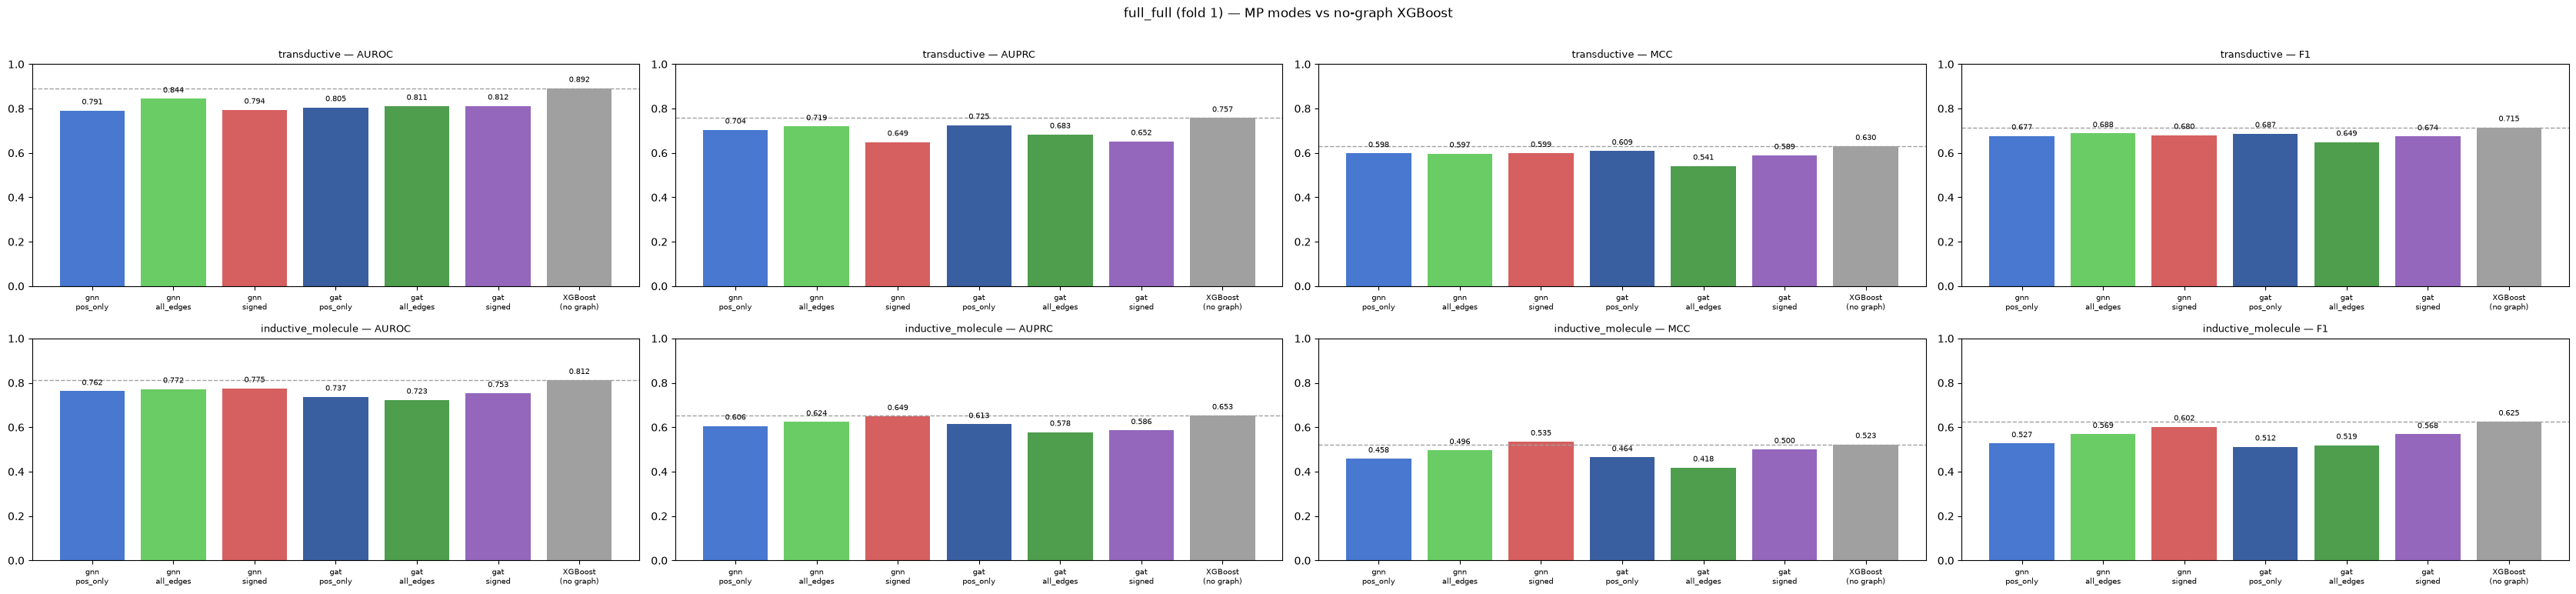

In [92]:
# Main comparison: 3 MP modes x {gnn, gat}, both regimes
specs = [("gnn pos_only", GNN_C["pos_only"], "gnn", "pos_only"),
         ("gnn all_edges", GNN_C["all_edges"], "gnn", "all_edges"),
         ("gnn signed",    GNN_C["signed"],    "gnn", "signed"),
         ("gat pos_only",  GAT_C["pos_only"],  "gat", "pos_only"),
         ("gat all_edges", GAT_C["all_edges"], "gat", "all_edges"),
         ("gat signed",    GAT_C["signed"],    "gat", "signed")]
plot_grid(specs, f"full_full (fold {FOLD}) — MP modes vs no-graph XGBoost",
          "graph_full_full_bars")

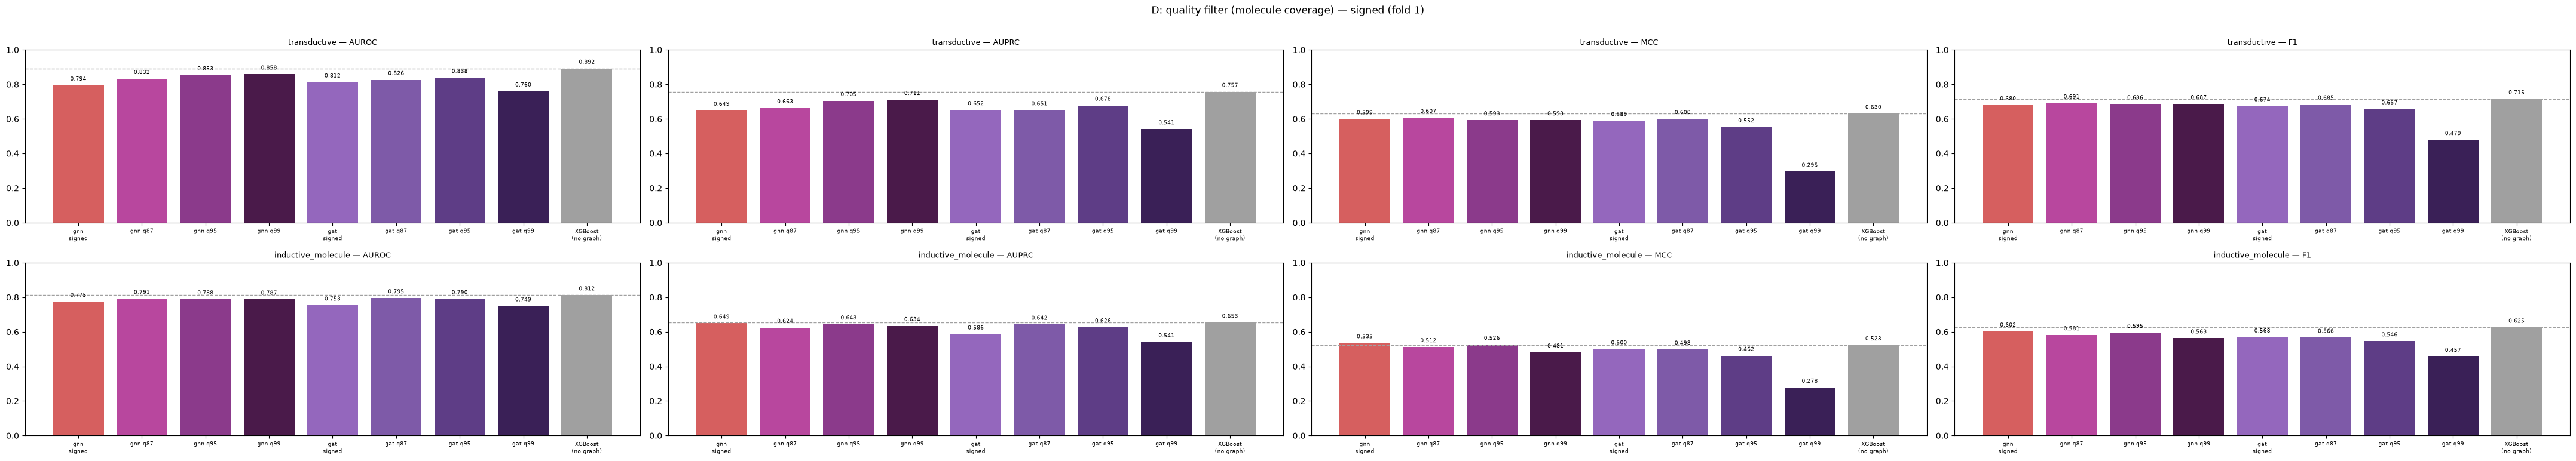

In [93]:
# D: molecule-coverage quality filter on the MP graph — signed, gnn & gat
specs = [("gnn signed",      "#D65F5F", "gnn", "signed"),
         ("gnn q87",         "#B8479E", "gnn", "signed_q87"),
         ("gnn q95",         "#8B3A8B", "gnn", "signed_q95"),
         ("gnn q99",         "#4A1A4A", "gnn", "signed_q99"),
         ("gat signed",      "#9467BD", "gat", "signed"),
         ("gat q87",         "#7E5AA8", "gat", "signed_q87"),
         ("gat q95",         "#5E3D86", "gat", "signed_q95"),
         ("gat q99",         "#3A2057", "gat", "signed_q99")]
plot_grid(specs, f"D: quality filter (molecule coverage) — signed (fold {FOLD})",
          "graph_full_full_quality", fs=6.5)

### D′: best-val vs last-epoch — **validation** metrics only

The D bars above use the XGBoost **test** probe, which was computed once on the **best-val** encoder —
these runs never saved the final-epoch weights, so a true *last-epoch test probe* isn't recoverable
for them (that's now added to the trainer for future runs). What we *can* show retroactively is the
per-epoch **validation** curve: best-val vs the value at epoch 1500 (decoder head, **not** the test
probe — do not compare these bars to D's). It quantifies how far each config drifts past its own optimum:
the drop is small for transductive (~0.02 AUPRC) but larger for inductive (~0.045), i.e. best-val
selection matters more in the cold-molecule regime.

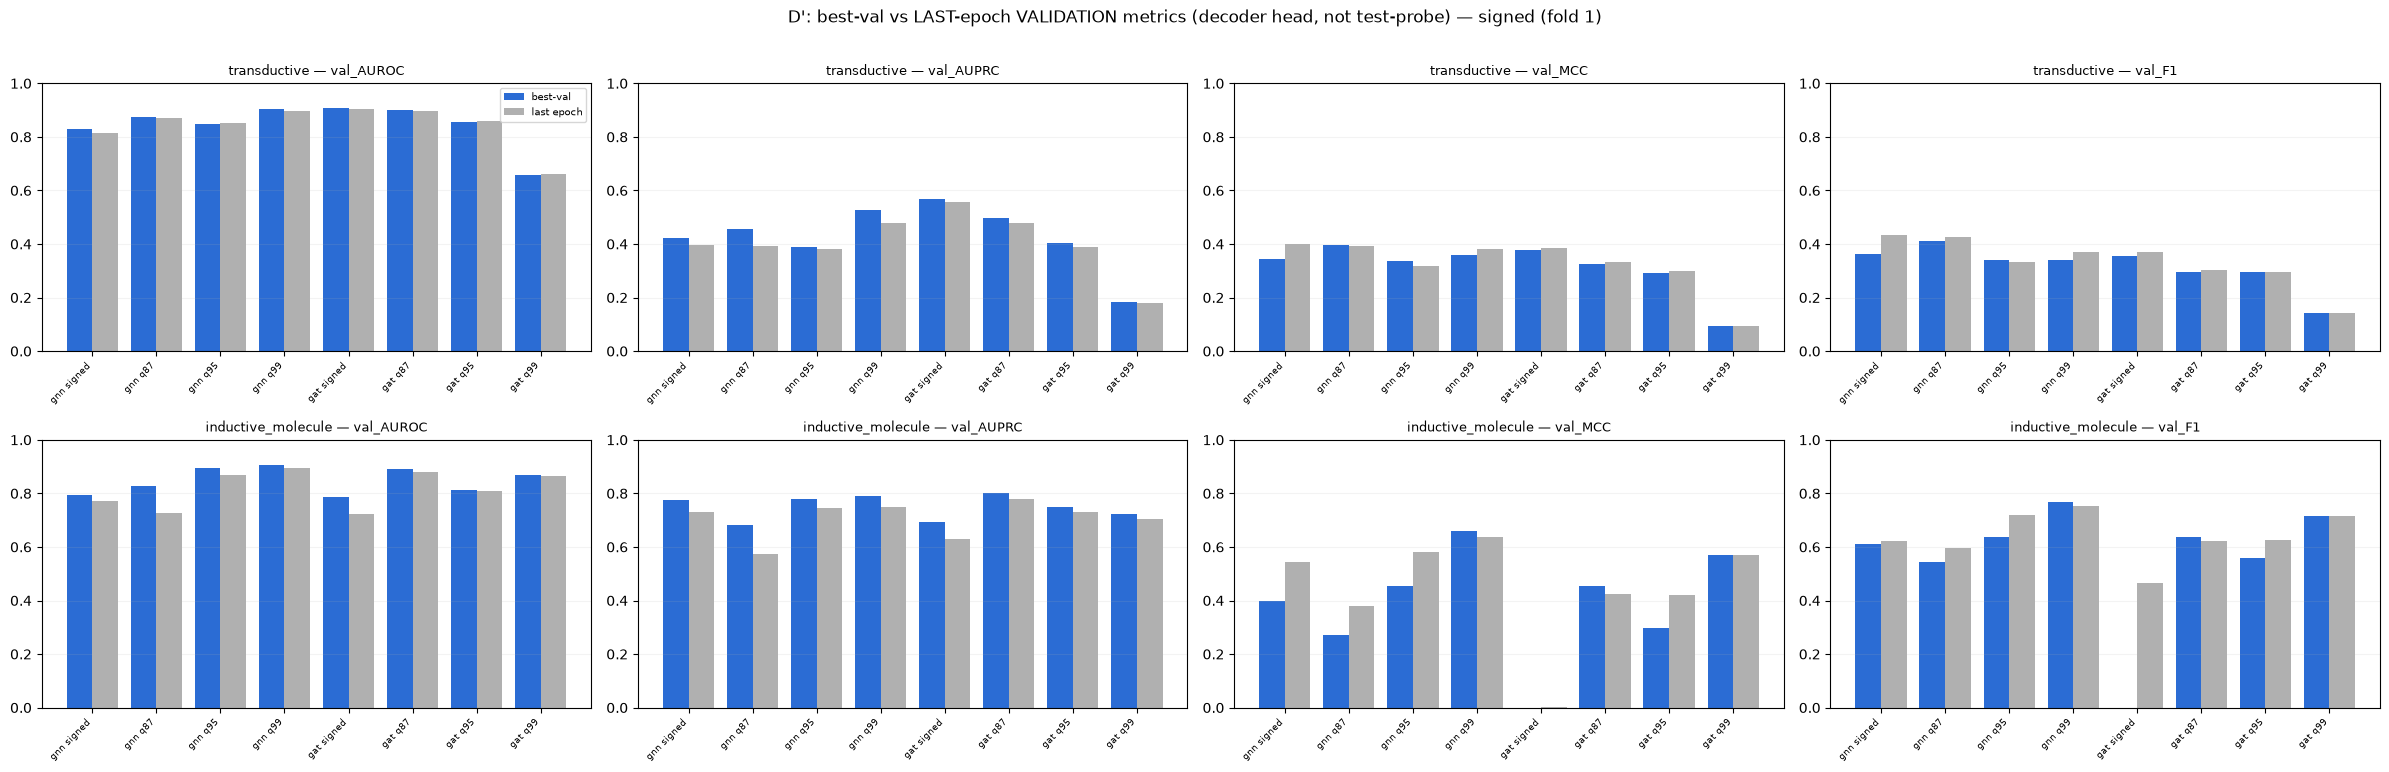

In [94]:
# D': best-val vs LAST-epoch VALIDATION metrics (decoder head, NOT the XGBoost test probe).
# Uses the per-epoch val curves from the history CSVs — the only last-epoch signal these runs kept.
HIST_DIRS = [ROOT / "results/graph/full_full/legacy/pre_v5/sweep_v3/full_full/history",
             ROOT / "results/graph/full_full/legacy/pre_v5/rerun_v3/full_full/history"]
D_CONFIGS = [("gnn", "signed", "gnn signed"), ("gnn", "signed_q87", "gnn q87"),
             ("gnn", "signed_q95", "gnn q95"), ("gnn", "signed_q99", "gnn q99"),
             ("gat", "signed", "gat signed"), ("gat", "signed_q87", "gat q87"),
             ("gat", "signed_q95", "gat q95"), ("gat", "signed_q99", "gat q99")]

def _hist(arch, variant, regime):
    fn = f"{arch}_{variant}_{regime}_fold{FOLD}.csv"
    for d in HIST_DIRS:
        if (d / fn).exists():
            return pd.read_csv(d / fn)
    return None

def _best_last(arch, variant, regime, metric):
    f = _hist(arch, variant, regime)
    if f is None or len(f) == 0:
        return np.nan, np.nan
    b = f.loc[f["val_AUPRC"].idxmax()]
    return b[f"val_{metric}"], f.iloc[-1][f"val_{metric}"]

labels = [c[2] for c in D_CONFIGS]
x = np.arange(len(D_CONFIGS)); w = 0.4
BEST_C, LAST_C = "#2B6CD4", "#B0B0B0"
fig, axes = plt.subplots(len(REGIMES), len(PLOT_METRICS),
                         figsize=(0.75 * len(D_CONFIGS) * len(PLOT_METRICS), 3.8 * len(REGIMES)))
axes = np.array(axes).reshape(len(REGIMES), len(PLOT_METRICS))
for ri, regime in enumerate(REGIMES):
    for mi, metric in enumerate(PLOT_METRICS):
        ax = axes[ri, mi]
        bvals, lvals = zip(*[_best_last(a, v, regime, metric) for a, v, _ in D_CONFIGS])
        ax.bar(x - w/2, bvals, w, color=BEST_C, label="best-val")
        ax.bar(x + w/2, lvals, w, color=LAST_C, label="last epoch")
        ax.set_title(f"{regime} — val_{metric}", fontsize=9); ax.set_ylim(0, 1)
        ax.set_xticks(x); ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=6.5)
        ax.grid(alpha=.15, axis="y")
        if ri == 0 and mi == 0:
            ax.legend(fontsize=7, loc="upper right")
fig.suptitle(f"D': best-val vs LAST-epoch VALIDATION metrics (decoder head, not test-probe) — signed (fold {FOLD})",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "notebooks/figures/graph_full_full_quality_lastvsbest.png", dpi=150, bbox_inches="tight")
plt.show()

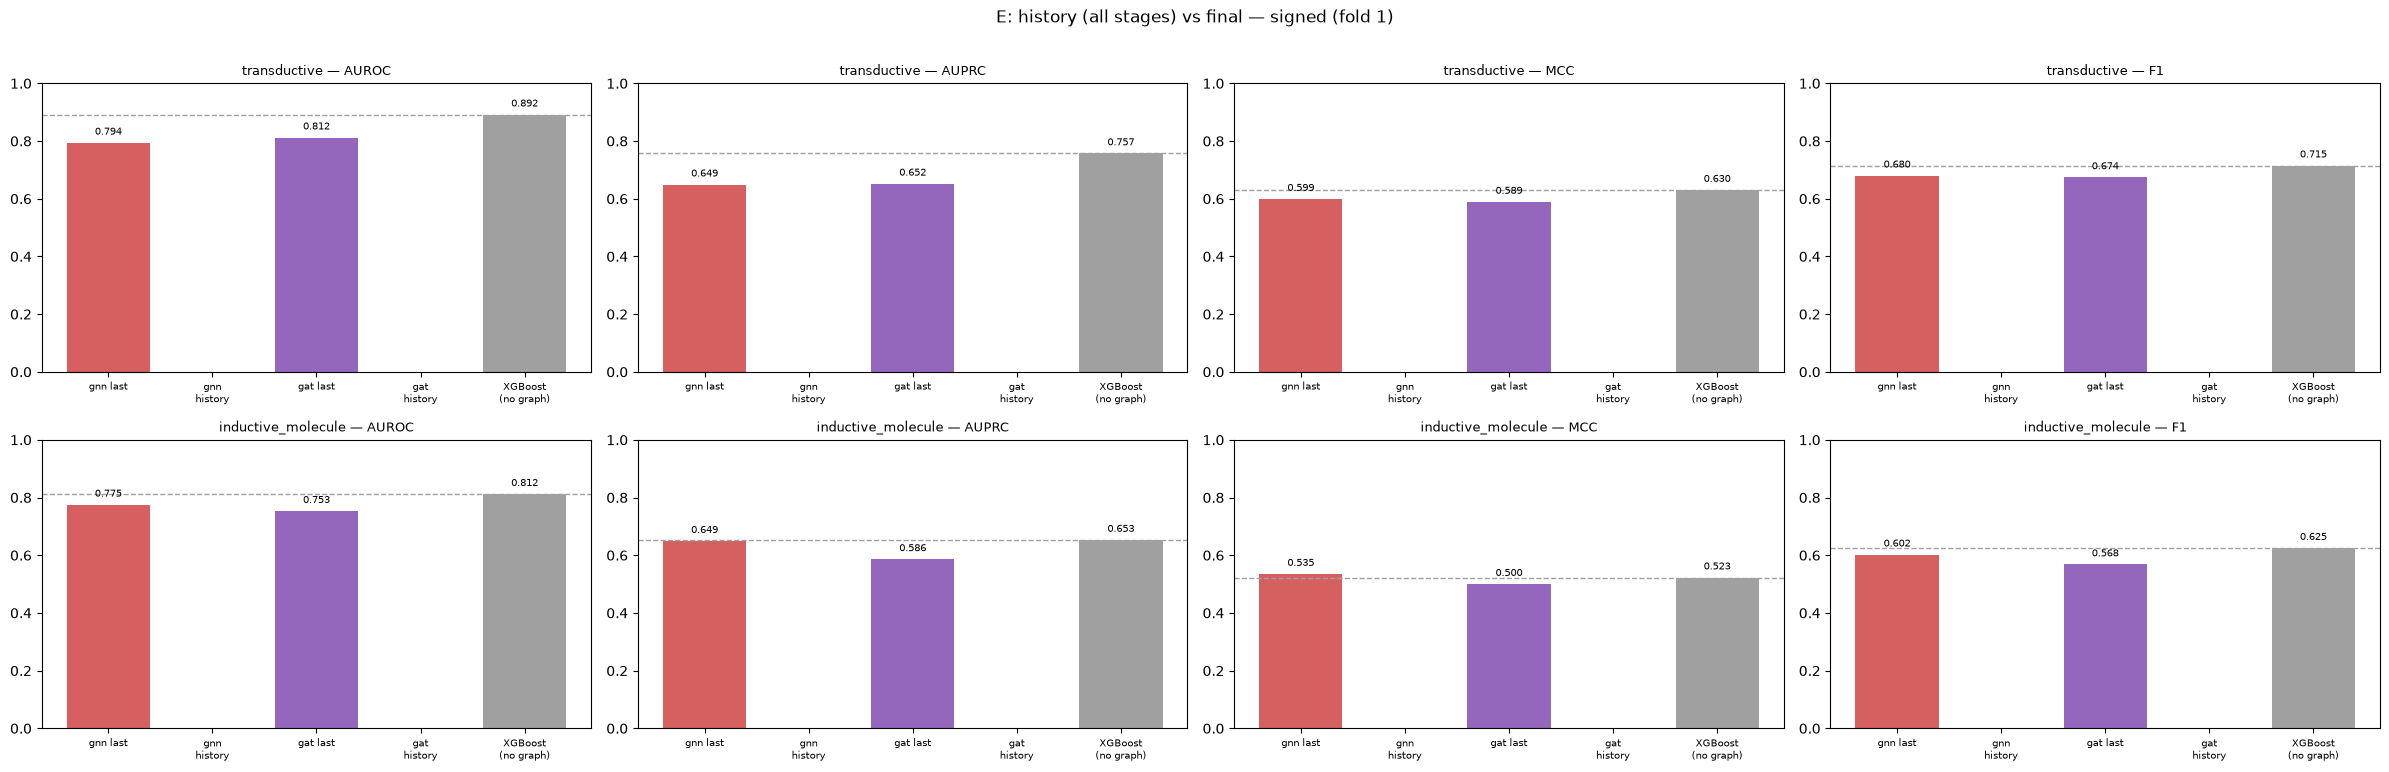

In [95]:
# E: concat all stages [x0||x1||x2] vs final z_prot — signed, gnn & gat
specs = [("gnn last",    "#D65F5F", "gnn", "signed"),
         ("gnn history", "#FF9F7F", "gnn", "signed_history"),
         ("gat last",    "#9467BD", "gat", "signed"),
         ("gat history", "#C5A3E8", "gat", "signed_history")]
plot_grid(specs, f"E: history (all stages) vs final — signed (fold {FOLD})",
          "graph_full_full_history")

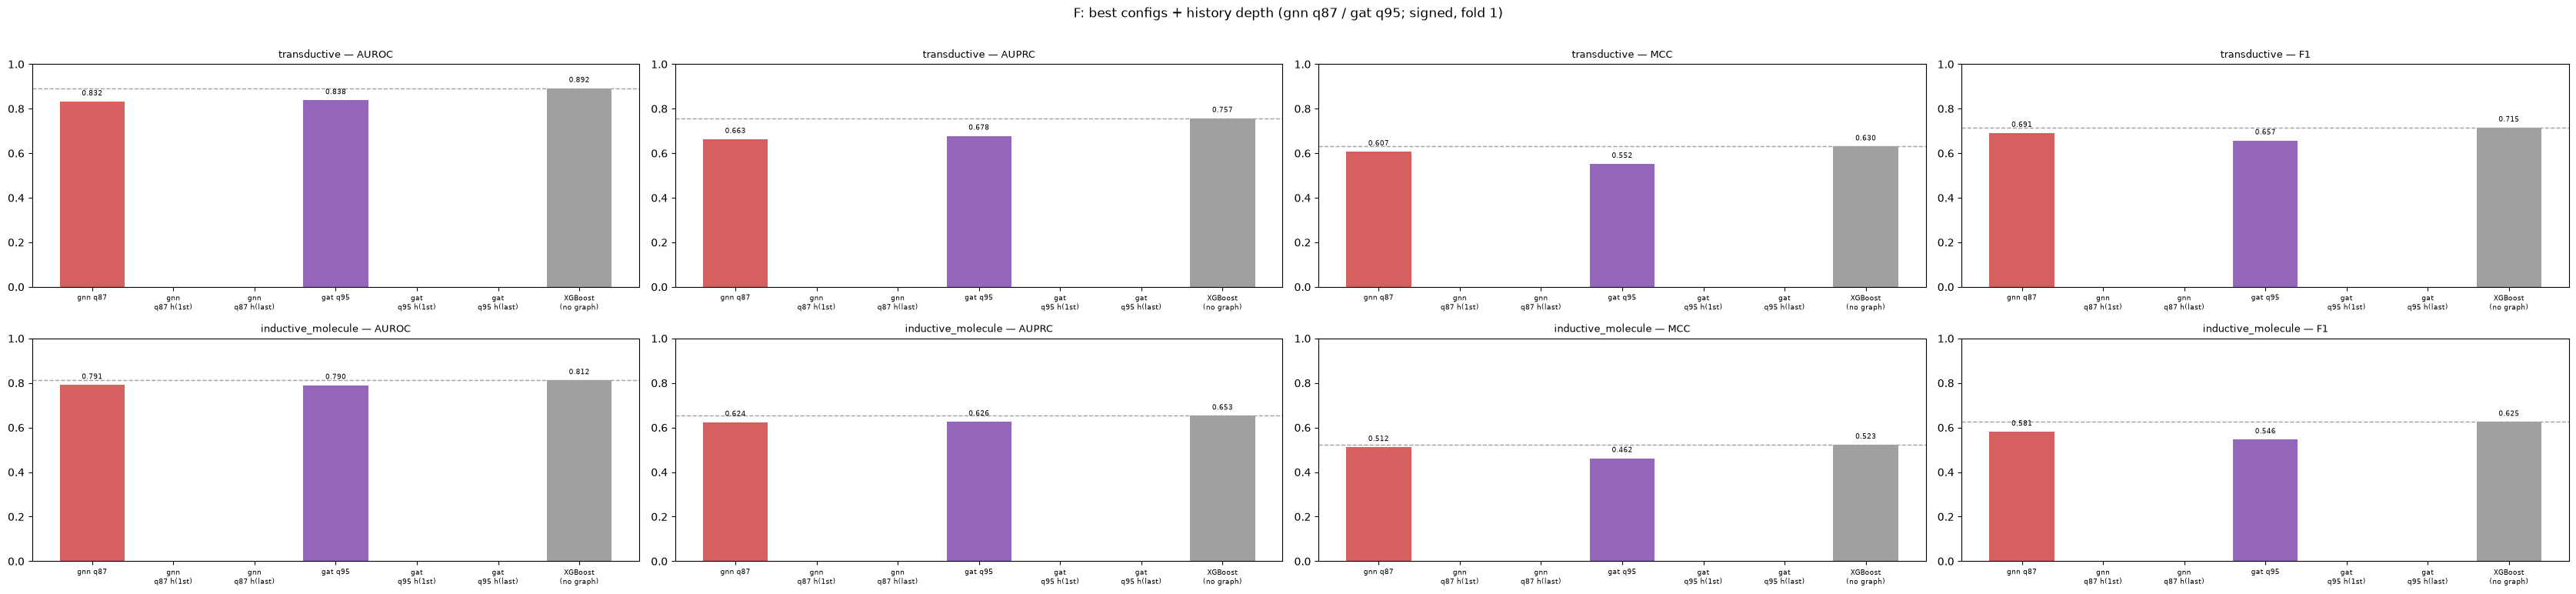

In [96]:
# F: best configs (gnn q87, gat q95) — final vs history(1st MP) vs history(last MP)
specs = [("gnn q87",            "#D65F5F", "gnn", "signed_q87"),
         ("gnn q87 h(1st)",     "#E8857A", "gnn", "signed_q87_hist1"),
         ("gnn q87 h(last)",    "#FF9F7F", "gnn", "signed_q87_history"),
         ("gat q95",            "#9467BD", "gat", "signed_q95"),
         ("gat q95 h(1st)",     "#B69AD8", "gat", "signed_q95_hist1"),
         ("gat q95 h(last)",    "#C5A3E8", "gat", "signed_q95_history")]
plot_grid(specs, f"F: best configs + history depth (gnn q87 / gat q95; signed, fold {FOLD})",
          "graph_full_full_best_history", fs=6.5)

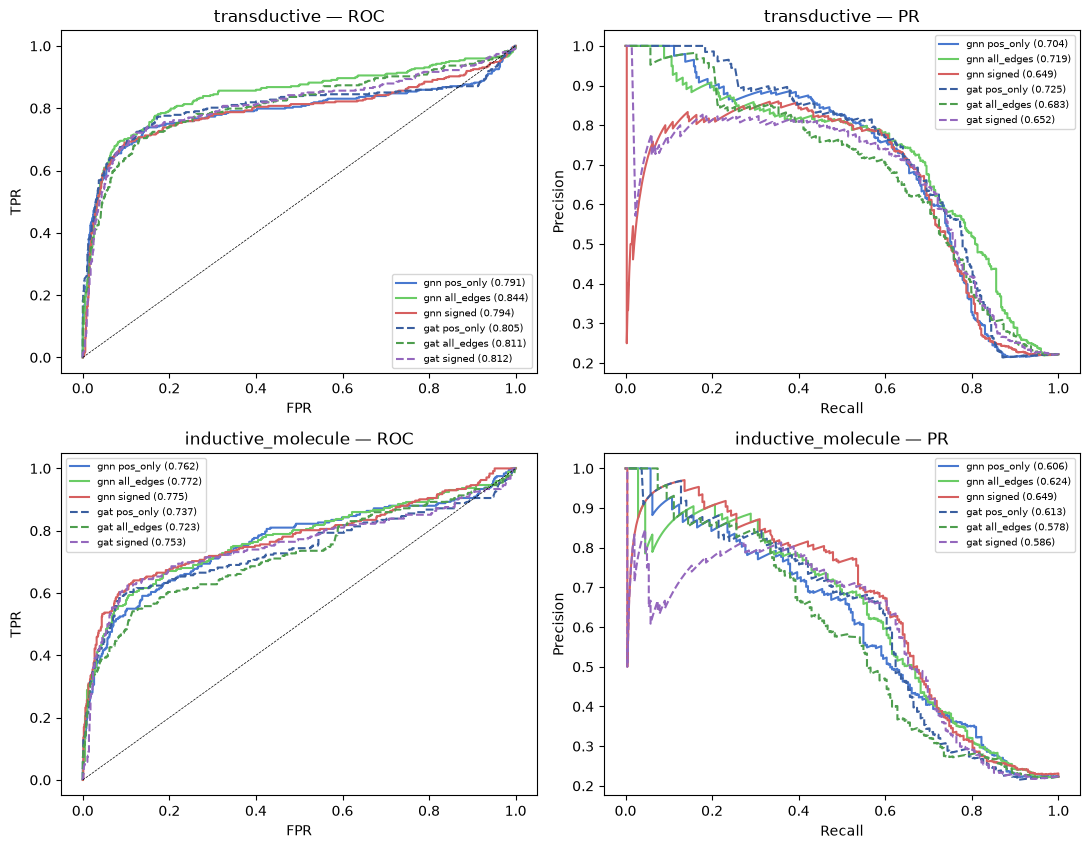

In [ ]:
# ROC + PR curves per regime, base MP modes only
BASE_VARS = [("gnn","pos_only"),("gnn","all_edges"),("gnn","signed"),
             ("gat","pos_only"),("gat","all_edges"),("gat","signed")]
COL = {("gnn",m): GNN_C[m] for m in GNN_C}; COL.update({("gat",m): GAT_C[m] for m in GAT_C})
fig, axes = plt.subplots(len(REGIMES), 2, figsize=(11, 4.3*len(REGIMES)))
axes = np.array(axes).reshape(len(REGIMES), 2)
for ri, regime in enumerate(REGIMES):
    ax_roc, ax_pr = axes[ri]
    for a, v in BASE_VARS:
        if (regime, a, v) not in preds: continue
        y, sc = preds[(regime, a, v)]
        fpr, tpr, _ = roc_curve(y, sc); prec, rec, _ = precision_recall_curve(y, sc)
        ls = "-" if a == "gnn" else "--"
        ax_roc.plot(fpr, tpr, color=COL[(a,v)], ls=ls, label=f"{a} {v} ({df.loc[(regime,a,v),'AUROC']:.3f})")
        ax_pr.plot(rec, prec, color=COL[(a,v)], ls=ls, label=f"{a} {v} ({df.loc[(regime,a,v),'AUPRC']:.3f})")
    ax_roc.plot([0,1],[0,1],"k--",lw=0.5)
    ax_roc.set(title=f"{regime} — ROC", xlabel="FPR", ylabel="TPR"); ax_roc.legend(fontsize=7)
    ax_pr.set(title=f"{regime} — PR", xlabel="Recall", ylabel="Precision"); ax_pr.legend(fontsize=7)
plt.tight_layout()
plt.savefig(ROOT/"notebooks/figures/graph_full_full_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## Как читать

- **Серый пунктир** в каждой ячейке — наш бустинг без графа на тех же парах (`results/full_full/tables/baselines.csv`). Вопрос: добавляет ли граф что-то поверх `ESM‖ChemBERTa→XGBoost`.
- **Строка 1 (transductive)** — узлы общие, тест = EC50-рёбра; канон-планка (5 фолдов) в `results/full_full/article_results/lorax_compare.csv`.
- **Строка 2 (inductive_molecule)** — молекулы тест-набора cold; своя планка.
- **D** — фильтр MP-графа по покрытию молекулы (q = квантиль числа измерений). Это ортогонально качеству ассая (primary/secondary/ec50) — фильтруем по тому, насколько молекула хорошо промерена.
- **E** — `[x0‖x1‖x2]` (все стадии MP) vs финальный `z_prot` в фичах probe.

Сборка данных: `train_graph_full_full.py --mp_mode signed [--mol_quality_q q] [--history] --regime {transductive,inductive_molecule}`.